## Plots 

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

data = [
    # embedding, model, domain, mean

    # ---------- Jina ----------
    ("Jina_V3", "MedGemma 27B", "med", 0.977),
    ("Jina_V3", "MedGemma 27B", "nonmed", 0.995),
    ("Jina_V3", "GPT OSS 120B", "med", 0.964),
    ("Jina_V3", "GPT OSS 120B", "nonmed", 0.980),
    ("Jina_V3", "SauerkrautLM 70B", "med", 0.964),
    ("Jina_V3", "SauerkrautLM 70B", "nonmed", 0.945),
    ("Jina_V3", "Llama 3.1 8B", "med", 0.948),
    ("Jina_V3", "Llama 3.1 8B", "nonmed", 0.978),

    # ---------- GTE ----------
    ("GTE", "MedGemma 27B", "med", 0.975),
    ("GTE", "MedGemma 27B", "nonmed", 0.991),
    ("GTE", "GPT OSS 120B", "med", 0.959),
    ("GTE", "GPT OSS 120B", "nonmed", 0.975),
    ("GTE", "SauerkrautLM 70B", "med", 0.969),
    ("GTE", "SauerkrautLM 70B", "nonmed", 0.956),
    ("GTE", "Llama 3.1 8B", "med", 0.941),
    ("GTE", "Llama 3.1 8B", "nonmed", 0.993),

    # ---------- BGE-M3 ----------
    ("BGE-M3", "MedGemma 27B", "med", 0.930),
    ("BGE-M3", "MedGemma 27B", "nonmed", 0.978),
    ("BGE-M3", "GPT OSS 120B", "med", 0.929),
    ("BGE-M3", "GPT OSS 120B", "nonmed", 0.946),
    ("BGE-M3", "SauerkrautLM 70B", "med", 0.925),
    ("BGE-M3", "SauerkrautLM 70B", "nonmed", 0.914),
    ("BGE-M3", "Llama 3.1 8B", "med", 0.891),
    ("BGE-M3", "Llama 3.1 8B", "nonmed", 0.965),

    # ---------- German Semantic ----------
    ("Aari1995", "MedGemma 27B", "med", 0.979),
    ("Aari1995", "MedGemma 27B", "nonmed", 0.995),
    ("Aari1995", "GPT OSS 120B", "med", 0.981),
    ("Aari1995", "GPT OSS 120B", "nonmed", 0.994),
    ("Aari1995", "SauerkrautLM 70B", "med", 0.970),
    ("Aari1995", "SauerkrautLM 70B", "nonmed", 0.983),
    ("Aari1995", "Llama 3.1 8B", "med", 0.942),
    ("Aari1995", "Llama 3.1 8B", "nonmed", 0.991),

    # ---------- Llama Embedding ----------
    ("LlamaEmb", "MedGemma 27B", "med", 0.802),
    ("LlamaEmb", "MedGemma 27B", "nonmed", 0.879),
    ("LlamaEmb", "GPT OSS 120B", "med", 0.912),
    ("LlamaEmb", "GPT OSS 120B", "nonmed", 0.945),
    ("LlamaEmb", "SauerkrautLM 70B", "med", 0.943),
    ("LlamaEmb", "SauerkrautLM 70B", "nonmed", 0.863),
    ("LlamaEmb", "Llama 3.1 8B", "med", 0.911),
    ("LlamaEmb", "Llama 3.1 8B", "nonmed", 0.982),
]

df = pd.DataFrame(data, columns=["embedding", "model", "domain", "mean"])


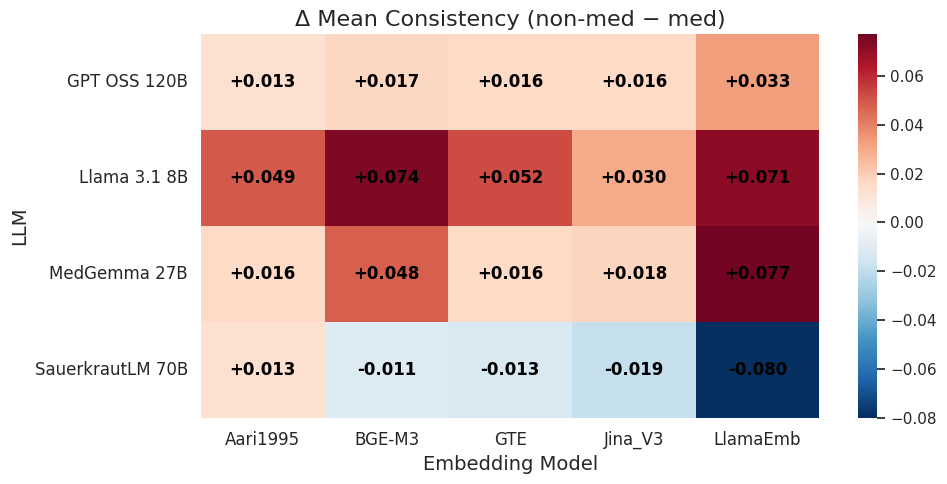

In [3]:
pivot = df.pivot_table(
    index=["model", "embedding"],
    columns="domain",
    values="mean"
).reset_index()

pivot["delta"] = pivot["nonmed"] - pivot["med"]

heatmap_data = pivot.pivot(
    index="model",
    columns="embedding",
    values="delta"
)

plt.figure(figsize=(10, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="+.3f",
    cmap="RdBu_r",
    center=0,
    annot_kws={"size": 12, "weight": "bold", "color": "black"}

)
plt.title("Δ Mean Consistency (non-med − med)", fontsize=16)
plt.xlabel("Embedding Model", fontsize=14)
plt.ylabel("LLM", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
output_filename = "Δ Mean Consistency .png"
plt.savefig(output_filename, dpi=300)
plt.show()


# für Kosinusähnlichkeit

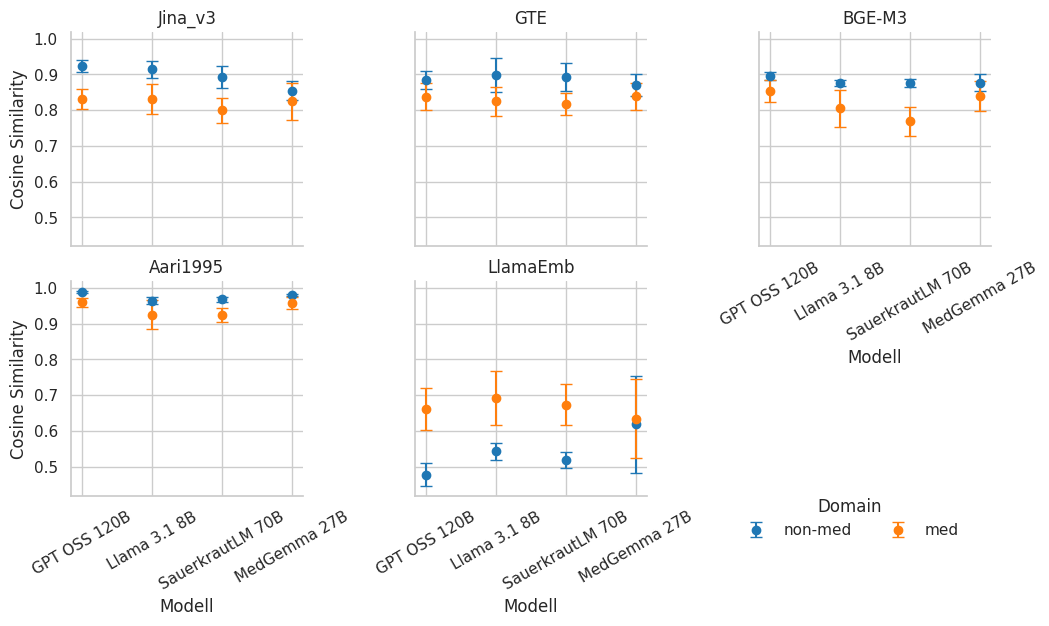

In [4]:
sns.set_theme(style="whitegrid")

# ======================================================
# Daten
# ======================================================
data = [
    # embedding, model, domain, mean, std

    # ---------- Jina v3 ----------
    ("Jina_v3", "GPT OSS 120B", "non-med", 0.923054, 0.016990),
    ("Jina_v3", "Llama 3.1 8B", "non-med", 0.914861, 0.023453),
    ("Jina_v3", "SauerkrautLM 70B", "non-med", 0.892358, 0.030227),
    ("Jina_v3", "MedGemma 27B", "non-med", 0.855033, 0.027554),

    ("Jina_v3", "GPT OSS 120B", "med", 0.831045, 0.028638),
    ("Jina_v3", "Llama 3.1 8B", "med", 0.830129, 0.042229),
    ("Jina_v3", "SauerkrautLM 70B", "med", 0.799833, 0.034577),
    ("Jina_v3", "MedGemma 27B", "med", 0.825300, 0.051461),

    # ---------- GTE ----------
    ("GTE", "Llama 3.1 8B", "non-med", 0.898056, 0.047682),
    ("GTE", "SauerkrautLM 70B", "non-med", 0.893132, 0.038332),
    ("GTE", "GPT OSS 120B", "non-med", 0.885344, 0.025432),
    ("GTE", "MedGemma 27B", "non-med", 0.870068, 0.031653),

    ("GTE", "MedGemma 27B", "med", 0.838942, 0.037642),
    ("GTE", "GPT OSS 120B", "med", 0.836942, 0.037750),
    ("GTE", "Llama 3.1 8B", "med", 0.825440, 0.040645),
    ("GTE", "SauerkrautLM 70B", "med", 0.817691, 0.030326),

    # ---------- BGE-M3 ----------
    ("BGE-M3", "GPT OSS 120B", "non-med", 0.896267, 0.011543),
    ("BGE-M3", "MedGemma 27B", "non-med", 0.877103, 0.023000),
    ("BGE-M3", "Llama 3.1 8B", "non-med", 0.875931, 0.008433),
    ("BGE-M3", "SauerkrautLM 70B", "non-med", 0.875147, 0.011407),

    ("BGE-M3", "GPT OSS 120B", "med", 0.853286, 0.031596),
    ("BGE-M3", "MedGemma 27B", "med", 0.838681, 0.041977),
    ("BGE-M3", "Llama 3.1 8B", "med", 0.805668, 0.051620),
    ("BGE-M3", "SauerkrautLM 70B", "med", 0.769068, 0.040413),

    # ---------- German V3b ----------
    ("Aari1995", "GPT OSS 120B", "non-med", 0.989128, 0.002408),
    ("Aari1995", "MedGemma 27B", "non-med", 0.979671, 0.003073),
    ("Aari1995", "SauerkrautLM 70B", "non-med", 0.969040, 0.006858),
    ("Aari1995", "Llama 3.1 8B", "non-med", 0.964799, 0.010136),

    ("Aari1995", "GPT OSS 120B", "med", 0.960181, 0.013114),
    ("Aari1995", "MedGemma 27B", "med", 0.958984, 0.016845),
    ("Aari1995", "Llama 3.1 8B", "med", 0.925447, 0.039921),
    ("Aari1995", "SauerkrautLM 70B", "med", 0.923617, 0.019780),

    # ---------- Llama Embedding ----------
    ("LlamaEmb", "MedGemma 27B", "non-med", 0.618791, 0.136208),
    ("LlamaEmb", "Llama 3.1 8B", "non-med", 0.542411, 0.023389),
    ("LlamaEmb", "SauerkrautLM 70B", "non-med", 0.518029, 0.022723),
    ("LlamaEmb", "GPT OSS 120B", "non-med", 0.477299, 0.031543),

    ("LlamaEmb", "Llama 3.1 8B", "med", 0.691813, 0.075427),
    ("LlamaEmb", "SauerkrautLM 70B", "med", 0.673287, 0.057974),
    ("LlamaEmb", "GPT OSS 120B", "med", 0.661290, 0.057700),
    ("LlamaEmb", "MedGemma 27B", "med", 0.634648, 0.111624),
]

df = pd.DataFrame(
    data,
    columns=["embedding", "model", "domain", "mean", "std"]
)

# ======================================================
# Point-Range-Plot
# ======================================================
g = sns.FacetGrid(
    df,
    col="embedding",
    col_wrap=3,
    height=3.5,
    sharey=True
)

def point_range(data, **kwargs):
    for domain, color in zip(["non-med", "med"], ["tab:blue", "tab:orange"]):
        d = data[data["domain"] == domain]
        plt.errorbar(
            d["model"],
            d["mean"],
            yerr=d["std"],
            fmt="o",
            capsize=4,
            label=domain,
            color=color
        )

g.map_dataframe(point_range)

g.set_axis_labels("Modell", "Cosine Similarity")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=30)

# ===== Legende unten, mit Abstand =====
handles, labels = g.axes.flat[0].get_legend_handles_labels()

for ax in g.axes.flat:
    if ax.legend_ is not None:
        ax.legend_.remove()

g.fig.subplots_adjust(bottom=0.28)

g.fig.legend(
    handles,
    labels,
    title="Domain",
    loc="lower center",
    bbox_to_anchor=(0.8, 0.2),
    ncol=2,
    frameon=False
)

output_filename = "point_range_plot.png"
plt.savefig(output_filename, dpi=300)
plt.show()



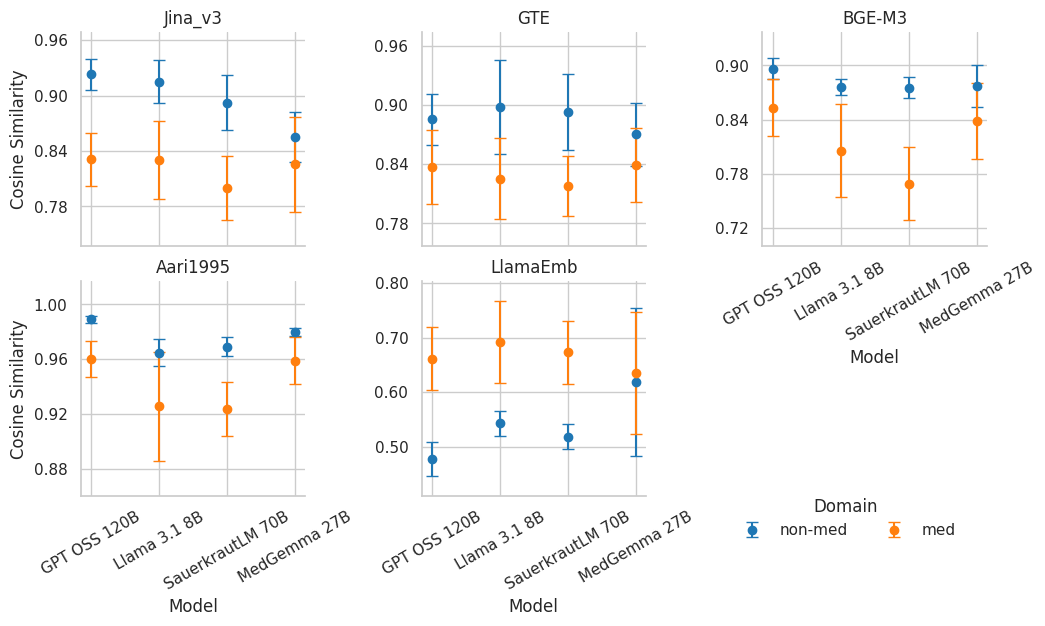

In [5]:
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

sns.set_theme(style="whitegrid")

data = [
    ("Jina_v3", "GPT OSS 120B", "non-med", 0.923054, 0.016990),
    ("Jina_v3", "Llama 3.1 8B", "non-med", 0.914861, 0.023453),
    ("Jina_v3", "SauerkrautLM 70B", "non-med", 0.892358, 0.030227),
    ("Jina_v3", "MedGemma 27B", "non-med", 0.855033, 0.027554),
    ("Jina_v3", "GPT OSS 120B", "med", 0.831045, 0.028638),
    ("Jina_v3", "Llama 3.1 8B", "med", 0.830129, 0.042229),
    ("Jina_v3", "SauerkrautLM 70B", "med", 0.799833, 0.034577),
    ("Jina_v3", "MedGemma 27B", "med", 0.825300, 0.051461),

    ("GTE", "Llama 3.1 8B", "non-med", 0.898056, 0.047682),
    ("GTE", "SauerkrautLM 70B", "non-med", 0.893132, 0.038332),
    ("GTE", "GPT OSS 120B", "non-med", 0.885344, 0.025432),
    ("GTE", "MedGemma 27B", "non-med", 0.870068, 0.031653),
    ("GTE", "MedGemma 27B", "med", 0.838942, 0.037642),
    ("GTE", "GPT OSS 120B", "med", 0.836942, 0.037750),
    ("GTE", "Llama 3.1 8B", "med", 0.825440, 0.040645),
    ("GTE", "SauerkrautLM 70B", "med", 0.817691, 0.030326),

    ("BGE-M3", "GPT OSS 120B", "non-med", 0.896267, 0.011543),
    ("BGE-M3", "MedGemma 27B", "non-med", 0.877103, 0.023000),
    ("BGE-M3", "Llama 3.1 8B", "non-med", 0.875931, 0.008433),
    ("BGE-M3", "SauerkrautLM 70B", "non-med", 0.875147, 0.011407),
    ("BGE-M3", "GPT OSS 120B", "med", 0.853286, 0.031596),
    ("BGE-M3", "MedGemma 27B", "med", 0.838681, 0.041977),
    ("BGE-M3", "Llama 3.1 8B", "med", 0.805668, 0.051620),
    ("BGE-M3", "SauerkrautLM 70B", "med", 0.769068, 0.040413),

    ("Aari1995", "GPT OSS 120B", "non-med", 0.989128, 0.002408),
    ("Aari1995", "MedGemma 27B", "non-med", 0.979671, 0.003073),
    ("Aari1995", "SauerkrautLM 70B", "non-med", 0.969040, 0.006858),
    ("Aari1995", "Llama 3.1 8B", "non-med", 0.964799, 0.010136),
    ("Aari1995", "GPT OSS 120B", "med", 0.960181, 0.013114),
    ("Aari1995", "MedGemma 27B", "med", 0.958984, 0.016845),
    ("Aari1995", "Llama 3.1 8B", "med", 0.925447, 0.039921),
    ("Aari1995", "SauerkrautLM 70B", "med", 0.923617, 0.019780),

    ("LlamaEmb", "MedGemma 27B", "non-med", 0.618791, 0.136208),
    ("LlamaEmb", "Llama 3.1 8B", "non-med", 0.542411, 0.023389),
    ("LlamaEmb", "SauerkrautLM 70B", "non-med", 0.518029, 0.022723),
    ("LlamaEmb", "GPT OSS 120B", "non-med", 0.477299, 0.031543),
    ("LlamaEmb", "Llama 3.1 8B", "med", 0.691813, 0.075427),
    ("LlamaEmb", "SauerkrautLM 70B", "med", 0.673287, 0.057974),
    ("LlamaEmb", "GPT OSS 120B", "med", 0.661290, 0.057700),
    ("LlamaEmb", "MedGemma 27B", "med", 0.634648, 0.111624),
]
df = pd.DataFrame(
    data,
    columns=["embedding", "model", "domain", "mean", "std"]
)

# ======================================================
# Plot
# ======================================================
g = sns.FacetGrid(
    df,
    col="embedding",
    col_wrap=3,
    height=3.5,
    sharey=False
)

def point_range(data, **kwargs):
    for domain, color in zip(["non-med", "med"], ["tab:blue", "tab:orange"]):
        d = data[data["domain"] == domain]
        plt.errorbar(
            d["model"],
            d["mean"],
            yerr=d["std"],
            fmt="o",
            capsize=4,
            label=domain,
            color=color
        )

g.map_dataframe(point_range)

g.set_axis_labels("Model", "Cosine Similarity")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=30)

    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin - 0.02, ymax + 0.02)

    ax.yaxis.set_major_locator(MaxNLocator(4))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# ======================================================
# Legende
# ======================================================
handles, labels = g.axes.flat[0].get_legend_handles_labels()

for ax in g.axes.flat:
    if ax.legend_ is not None:
        ax.legend_.remove()

g.fig.subplots_adjust(bottom=0.28)

g.fig.legend(
    handles,
    labels,
    title="Domain",
    loc="lower center",
    bbox_to_anchor=(0.8, 0.2),
    ncol=2,
    frameon=False
)

plt.savefig("point_range_plot2.png", dpi=300, bbox_inches="tight")
plt.show()

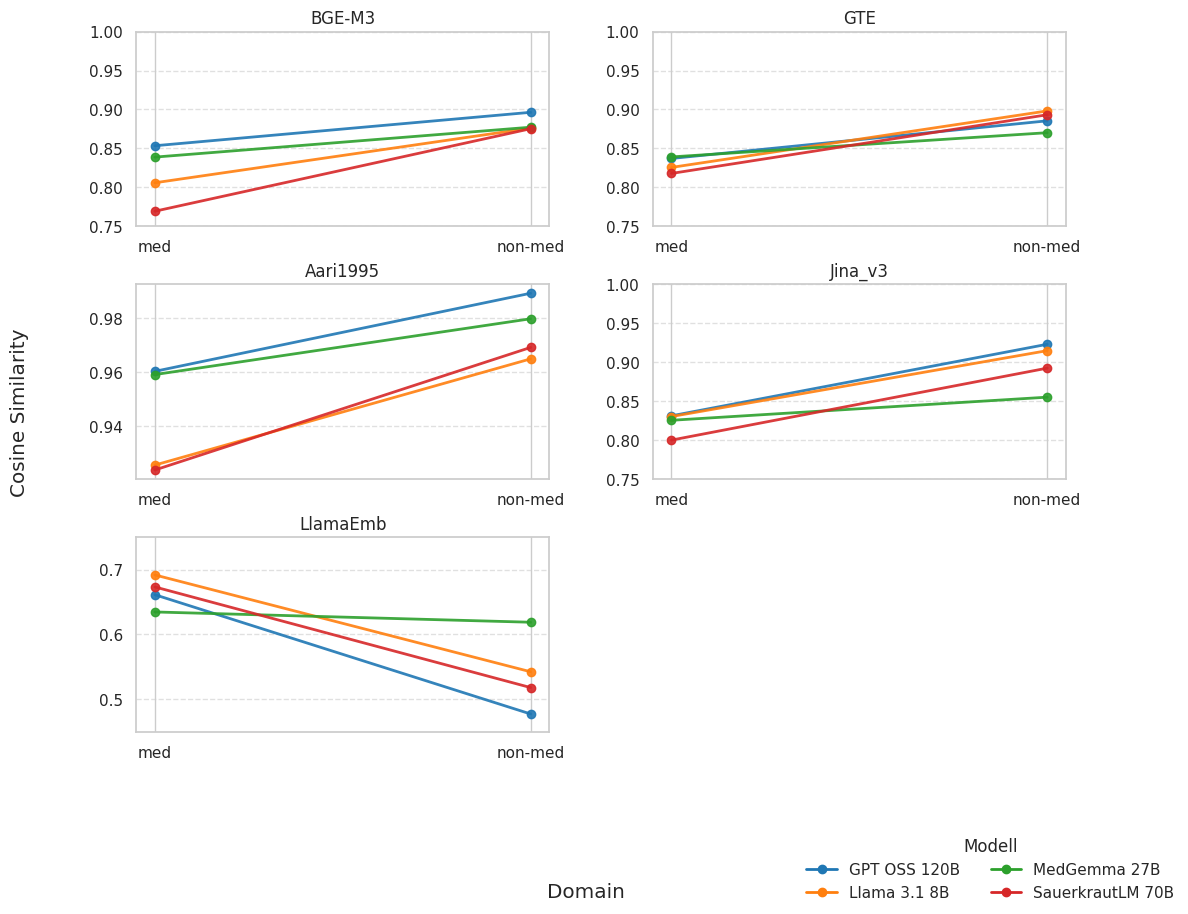

In [6]:
sns.set_theme(style="whitegrid")

# ======================================================
# Daten
# ======================================================
data = [
    ("BGE-M3","GPT OSS 120B","med",0.853286), ("BGE-M3","GPT OSS 120B","non-med",0.896267),
    ("BGE-M3","Llama 3.1 8B","med",0.805668), ("BGE-M3","Llama 3.1 8B","non-med",0.875931),
    ("BGE-M3","SauerkrautLM 70B","med",0.769068), ("BGE-M3","SauerkrautLM 70B","non-med",0.875147),
    ("BGE-M3","MedGemma 27B","med",0.838681), ("BGE-M3","MedGemma 27B","non-med",0.877103),

    ("GTE","GPT OSS 120B","med",0.836942), ("GTE","GPT OSS 120B","non-med",0.885344),
    ("GTE","Llama 3.1 8B","med",0.825440), ("GTE","Llama 3.1 8B","non-med",0.898056),
    ("GTE","SauerkrautLM 70B","med",0.817691), ("GTE","SauerkrautLM 70B","non-med",0.893132),
    ("GTE","MedGemma 27B","med",0.838942), ("GTE","MedGemma 27B","non-med",0.870068),

    ("Aari1995","GPT OSS 120B","med",0.960181), ("Aari1995","GPT OSS 120B","non-med",0.989128),
    ("Aari1995","Llama 3.1 8B","med",0.925447), ("Aari1995","Llama 3.1 8B","non-med",0.964799),
    ("Aari1995","SauerkrautLM 70B","med",0.923617), ("Aari1995","SauerkrautLM 70B","non-med",0.969040),
    ("Aari1995","MedGemma 27B","med",0.958984), ("Aari1995","MedGemma 27B","non-med",0.979671),

    ("Jina_v3","GPT OSS 120B","med",0.831045), ("Jina_v3","GPT OSS 120B","non-med",0.923054),
    ("Jina_v3","Llama 3.1 8B","med",0.830129), ("Jina_v3","Llama 3.1 8B","non-med",0.914861),
    ("Jina_v3","SauerkrautLM 70B","med",0.799833), ("Jina_v3","SauerkrautLM 70B","non-med",0.892358),
    ("Jina_v3","MedGemma 27B","med",0.825300), ("Jina_v3","MedGemma 27B","non-med",0.855033),

    ("LlamaEmb","GPT OSS 120B","med",0.661290), ("LlamaEmb","GPT OSS 120B","non-med",0.477299),
    ("LlamaEmb","Llama 3.1 8B","med",0.691813), ("LlamaEmb","Llama 3.1 8B","non-med",0.542411),
    ("LlamaEmb","SauerkrautLM 70B","med",0.673287), ("LlamaEmb","SauerkrautLM 70B","non-med",0.518029),
    ("LlamaEmb","MedGemma 27B","med",0.634648), ("LlamaEmb","MedGemma 27B","non-med",0.618791),
]

df = pd.DataFrame(data, columns=["embedding","model","domain","mean"])

pivot = df.pivot_table(
    index=["embedding","model"],
    columns="domain",
    values="mean"
).reset_index()

# ======================================================
# Setup
# ======================================================
embeddings = ["BGE-M3", "GTE", "Aari1995", "Jina_v3", "LlamaEmb"]
models = pivot["model"].unique()

palette = dict(zip(models, sns.color_palette("tab10", len(models))))

fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey=False)
axes = axes.flatten()

# ======================================================
# Plot
# ======================================================
for ax, emb in zip(axes, embeddings):
    d = pivot[pivot["embedding"] == emb]

    for _, row in d.iterrows():
        ax.plot(
            ["med", "non-med"],
            [row["med"], row["non-med"]],
            marker="o",
            linewidth=2,
            color=palette[row["model"]],
            alpha=0.9
        )

    ax.set_title(emb)
    ax.set_xticks(["med", "non-med"])
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    # 🔍 Zoom je Embedding
    if emb in ["BGE-M3", "GTE", "German_V3b", "Jina_v3"]:
        ax.set_ylim(0.78, 1.0)
        ax.set_yticks([0.75,0.8, 0.85, 0.9, 0.95, 1.0])
    elif emb == "LlamaEmb":
        ax.set_ylim(0.45, 0.75)
        ax.set_yticks([0.5, 0.6, 0.7])

# Leeres Panel ausblenden
for i in range(len(embeddings), len(axes)):
    axes[i].axis("off")

# ======================================================
# Gemeinsame Beschriftung & Legende
# ======================================================
fig.supxlabel("Domain")
fig.supylabel("Cosine Similarity")

handles = [
    plt.Line2D([0], [0], color=palette[m], lw=2, marker="o", label=m)
    for m in models
]

fig.legend(
    handles=handles,
    title="Modell",
    loc="lower right",
    ncol=2,
    frameon=False
)

fig.subplots_adjust(bottom=0.18, wspace=0.25, hspace=0.3)



output_filename = "Slopegraphs.png"
plt.savefig(output_filename, dpi=300)

plt.show()


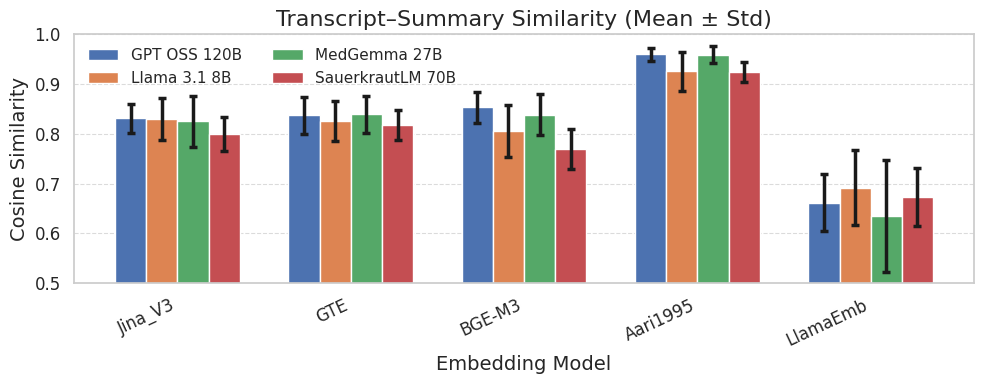

In [7]:
import numpy as np
# ---- Daten ----
models = [
    "GPT OSS 120B",
    "Llama 3.1 8B",
    "MedGemma 27B",
    "SauerkrautLM 70B",
]

embeddings = [
    "Jina_V3",
    "GTE",
    "BGE-M3",
    "Aari1995",
    "LlamaEmb",
]


#Spalten = Embedding
#Zeilen =LLM

mean = np.array([
    [0.831045, 0.836942, 0.853286, 0.960181, 0.661290],
    [0.830129, 0.825440, 0.805668, 0.925447, 0.691813],
    [0.825300, 0.838942, 0.838681, 0.958984, 0.634648],
    [0.799833, 0.817691, 0.769068, 0.923617, 0.673287],
])

std = np.array([
    [0.028638, 0.037750, 0.031596, 0.013114, 0.057700],
    [0.042229, 0.040645, 0.051620, 0.039921, 0.075427],
    [0.051461, 0.037642, 0.041977, 0.016845, 0.111624],
    [0.034577, 0.030326, 0.040413, 0.019780, 0.057974],
])

# ---- Plot ----
x = np.arange(len(embeddings))
width = 0.18  # Breite der Balken

fig, ax = plt.subplots(figsize=(10, 4))

for i, model in enumerate(models):
    offset = (i - (len(models)-1)/2) * width
    ax.bar(
        x + offset,
        mean[i],
        width,
        yerr=std[i],
        capsize=3,
        
        error_kw=dict(elinewidth=2.5, capthick=2.5),
        label=model

    )

# ---- Layout ----
ax.set_xticks(x)
ax.set_xticklabels(embeddings, rotation=25, ha="right")
ax.set_ylabel("Cosine Similarity", fontsize=14)
ax.set_xlabel("Embedding Model", fontsize=14)
ax.set_title("Transcript–Summary Similarity (Mean ± Std)", fontsize=16)
ax.tick_params(axis='both', labelsize=12)
#0.50 fuer MedGemma
ax.set_ylim(0.50, 1.0)
ax.legend(ncols=2, fontsize=11, frameon=False)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.savefig("transcript_Summary_Similarity.png", dpi=300)
plt.show()

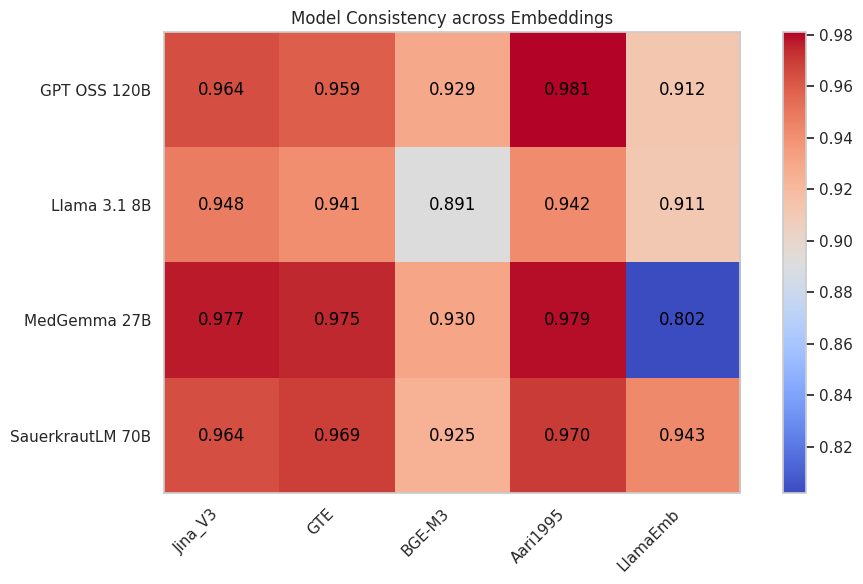

In [8]:

# -----------------------------
# Data
# -----------------------------
models = [
    "GPT OSS 120B",
    "Llama 3.1 8B",
    "MedGemma 27B",
    "SauerkrautLM 70B",
]

embeddings = [
    "Jina_V3",
    "GTE",
    "BGE-M3",
    "Aari1995",
    "LlamaEmb",
]

data = np.array([
    [0.964, 0.959, 0.929, 0.981, 0.912],
    [0.948, 0.941, 0.891, 0.942, 0.911],
    [0.977, 0.975, 0.930, 0.979, 0.802],
    [0.964, 0.969, 0.925, 0.970, 0.943],
])

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# WICHTIG: interpolation verhindert weiße Linien
im = ax.imshow(
    data,
    cmap="coolwarm",
    interpolation="nearest",
    resample=False
)

# Achsen
ax.set_xticks(np.arange(len(embeddings)))
ax.set_xticklabels(embeddings, rotation=45, ha="right")

ax.set_yticks(np.arange(len(models)))
ax.set_yticklabels(models)

# Grid sicher ausschalten
ax.grid(False)

# Werte in Zellen schreiben
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(
            j, i,
            f"{data[i, j]:.3f}",
            ha="center",
            va="center",
            color="black"
        )

# Colorbar
fig.colorbar(im, ax=ax)

# Titel
ax.set_title("Model Consistency across Embeddings")

plt.tight_layout()


plt.savefig("model_consistency.png", dpi=300, bbox_inches="tight")

plt.show()

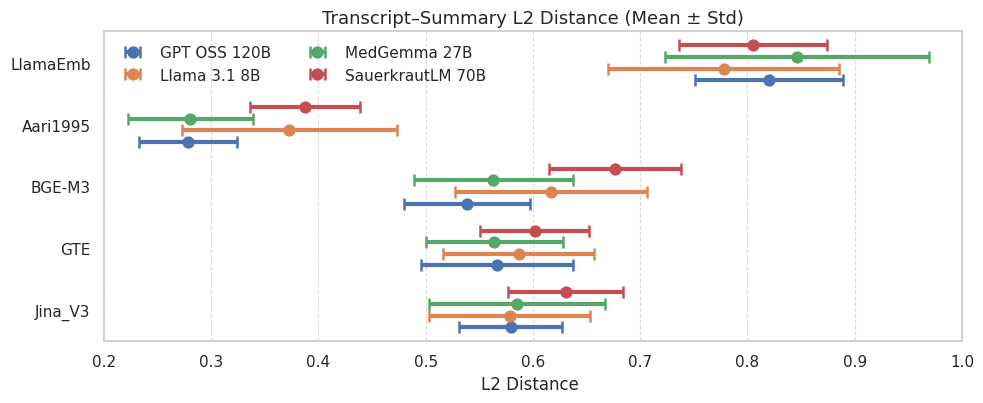

In [9]:

models = ["GPT OSS 120B", "Llama 3.1 8B", "MedGemma 27B", "SauerkrautLM 70B"]
embeddings = ["Jina_V3", "GTE", "BGE-M3", "Aari1995", "LlamaEmb"]

mean = np.array([
    [0.579245, 0.566712, 0.538573, 0.278504, 0.820213],
    [0.578342, 0.586652, 0.617068, 0.373000, 0.777759],
    [0.585380, 0.563973, 0.563238, 0.280483, 0.845996],
    [0.630696, 0.601717, 0.676842, 0.387460, 0.805437],
])

std = np.array([
    [0.047680, 0.070717, 0.058310, 0.045754, 0.068678],
    [0.074825, 0.070760, 0.089265, 0.100373, 0.107591],
    [0.082087, 0.063949, 0.073856, 0.058251, 0.123048],
    [0.053615, 0.050781, 0.061510, 0.051632, 0.068874],
])

fig, ax = plt.subplots(figsize=(10, 4.2))

# y-Positionen: pro Embedding ein Block, darin 4 Modelle
gap = 1.3
base = np.arange(len(embeddings)) * (len(models) + gap)
ypos = np.vstack([base + i for i in range(len(models))]).T  # (embeddings, models)

for i, m in enumerate(models):
    ax.errorbar(
        mean[i], ypos[:, i],
        xerr=std[i],
        fmt="o",
        markersize=7,         
        linewidth=2,          
        elinewidth=3,         
        capsize=4,            
        capthick=2,          
        markeredgewidth=1.8,  
        label=m
    )

# Embedding-Labels in der Mitte jedes Blocks
ax.set_yticks(base + (len(models) - 1) / 2)
ax.set_yticklabels(embeddings, fontsize=11)

ax.set_xlabel("L2 Distance ", fontsize=12)
ax.set_title("Transcript–Summary L2 Distance (Mean ± Std)", fontsize=13)

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

ax.grid(axis="y", visible=False)
ax.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.7)

ax.set_xlim(0.2, 1.0)
ax.legend(ncols=2, fontsize=11, frameon=False)


plt.tight_layout()
plt.savefig("L2_Distance.png", dpi=300, bbox_inches="tight")
plt.show()

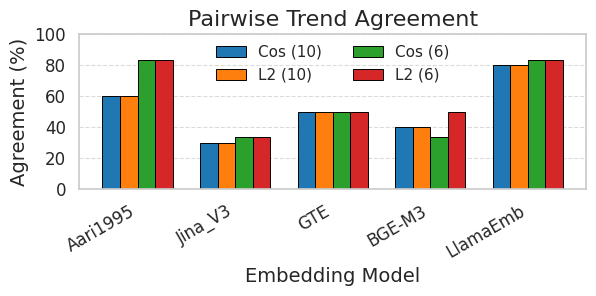

In [10]:

# -----------------------------
# Data
# -----------------------------
models = ["Aari1995", "Jina_V3", "GTE", "BGE-M3", "LlamaEmb"]

cosine_full = np.array([60, 30, 50, 40, 80])
l2_full     = np.array([60, 30, 50, 40, 80])

cosine_filt = np.array([83.3, 33.3, 50.0, 33.3, 83.3])
l2_filt     = np.array([83.3, 33.3, 50.0, 50.0, 83.3])

x = np.arange(len(models))
width = 0.18

# -----------------------------
# Style (paper-friendly)
# -----------------------------
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})

fig, ax = plt.subplots(figsize=(6, 3))

# Farben (gut unterscheidbar im Druck)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

# Balken mit dickeren Kanten
bars1 = ax.bar(x - 1.5*width, cosine_full, width,
               label="Cos (10)", color=colors[0],
               edgecolor="black", linewidth=0.7)

bars2 = ax.bar(x - 0.5*width, l2_full, width,
               label="L2 (10)", color=colors[1],
               edgecolor="black", linewidth=0.7)

bars3 = ax.bar(x + 0.5*width, cosine_filt, width,
               label="Cos (6)", color=colors[2],
               edgecolor="black", linewidth=0.7)

bars4 = ax.bar(x + 1.5*width, l2_filt, width,
               label="L2 (6)", color=colors[3],
               edgecolor="black", linewidth=0.7)

# Achsen
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha="right")

ax.set_xlabel("Embedding Model", fontsize=14)
ax.set_ylabel("Agreement (%)", fontsize=14)
ax.set_title("Pairwise Trend Agreement", fontsize=16)

ax.tick_params(axis='both', labelsize=12)

ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))


# Legende
ax.legend(
    ncols=2,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    fontsize=11
)
# Grid
ax.grid(axis="x", visible=False)
ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.7)


plt.tight_layout()

plt.savefig(
    "pairwise_trend_agreement.png",   
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

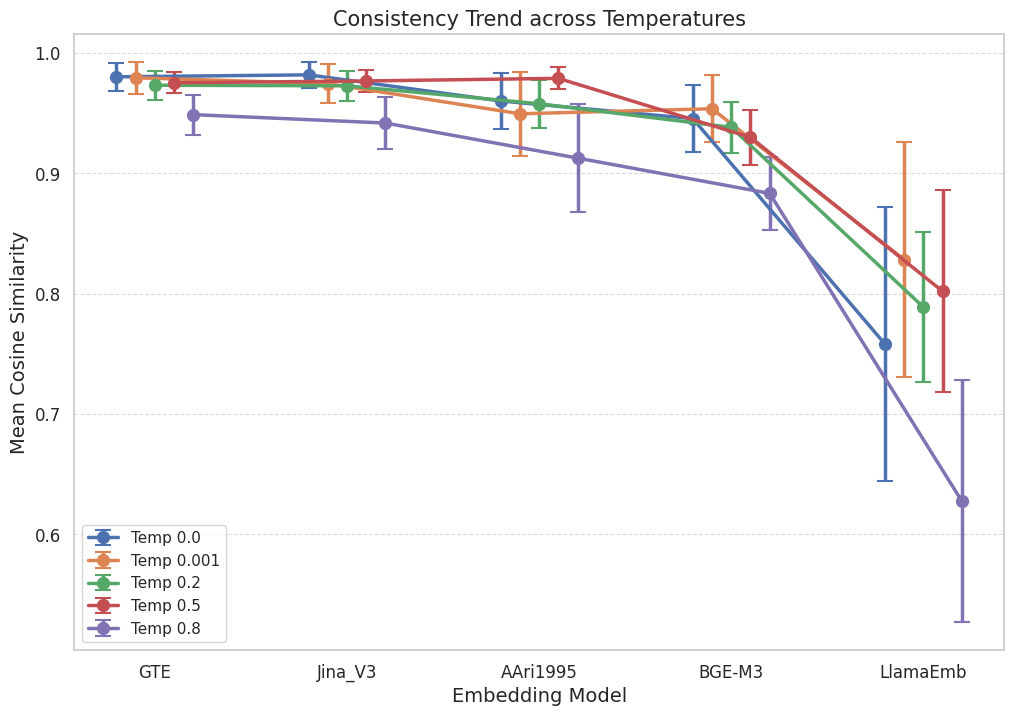

In [11]:


models = ["GTE", "Jina_V3", "AAri1995", "BGE-M3", "LlamaEmb"]
x = np.arange(len(models))

# Offsets für jede Linie
offsets = [-0.2, -0.1, 0.0, 0.1, 0.2]

# --- Daten ---
mean_00 = [0.980300, 0.981940, 0.960249, 0.945573, 0.758160]
std_00  = [0.011721, 0.010636, 0.023117, 0.027960, 0.113606]

mean_001 = [0.979529, 0.974697, 0.949584, 0.953777, 0.828353]
std_001  = [0.013110, 0.016512, 0.034822, 0.028008, 0.097756]

mean_02 = [0.973302, 0.972843, 0.957915, 0.938332, 0.788867]
std_02  = [0.011923, 0.012417, 0.020015, 0.021183,  0.062167]

mean_05 = [0.975352, 0.976858, 0.979042, 0.930038, 0.801991]
std_05  = [0.008610, 0.009532, 0.009176, 0.022895, 0.083941]

mean_08 = [0.948882, 0.941903, 0.912782, 0.883408, 0.627594]
std_08  = [0.016581, 0.021227, 0.044856, 0.030542, 0.100431]

plt.figure(figsize=(12, 8))

plt.errorbar(x + offsets[0], mean_00, yerr=std_00,
             marker='o', markersize=8,
             linewidth=2.5, elinewidth=2.5,
             capsize=6, capthick=2,
             markeredgewidth=1.5,
             label="Temp 0.0")

plt.errorbar(x + offsets[1], mean_001, yerr=std_001,
             marker='o', markersize=8,
             linewidth=2.5, elinewidth=2.5,
             capsize=6, capthick=2,
             markeredgewidth=1.5,
             label="Temp 0.001")

plt.errorbar(x + offsets[2], mean_02, yerr=std_02,
             marker='o', markersize=8,
             linewidth=2.5, elinewidth=2.5,
             capsize=6, capthick=2,
             markeredgewidth=1.5,
             label="Temp 0.2")

plt.errorbar(x + offsets[3], mean_05, yerr=std_05,
             marker='o', markersize=8,
             linewidth=2.5, elinewidth=2.5,
             capsize=6, capthick=2,
             markeredgewidth=1.5,
             label="Temp 0.5")

plt.errorbar(x + offsets[4], mean_08, yerr=std_08,
             marker='o', markersize=8,
             linewidth=2.5, elinewidth=2.5,
             capsize=6, capthick=2,
             markeredgewidth=1.5,
             label="Temp 0.8")

plt.xticks(x, models, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Embedding Model", fontsize=14)
plt.ylabel("Mean Cosine Similarity", fontsize=14)
plt.title("Consistency Trend across Temperatures", fontsize=15)
plt.legend(fontsize=11)



# Grid
plt.grid(axis="x", visible=False)
plt.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.7)

plt.savefig("consistency_trend.png", dpi=300, bbox_inches="tight")
plt.show()